In [1]:
# ═══════════════════════════════════════════════════════════════
# CHAINGUARDIAN AI - DEEP EXPLORATORY DATA ANALYSIS
# ═══════════════════════════════════════════════════════════════
# Day 1, Session 1A: Data Loading & Initial Cleaning
# Goal: Load dataset, fix critical issues, understand structure
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Setup complete - starting EDA...")

✅ Setup complete - starting EDA...


In [2]:
# Load dataset
df = pd.read_csv('/home/motafeq/projects/chainguardian-ai/data/chainguardian_features_clean.csv')
#/home/motafeq/projects/chainguardian-ai/data/chainguardian_features_clean.csv
print(f"📊 Dataset loaded: {len(df)} contracts, {len(df.columns)} columns")

# Identify column types
meta_cols = ['contract_id', 'contract_name', 'address', 'file_path', 'compiler_version']
vuln_cols = [c for c in df.columns if c.startswith('has_')]
feature_cols = [c for c in df.columns if c not in meta_cols + vuln_cols]

print(f"\n📋 Column breakdown:")
print(f"   Metadata: {len(meta_cols)}")
print(f"   Features: {len(feature_cols)}")
print(f"   Vulnerabilities: {len(vuln_cols)}")

# Display first few rows
df.head()

📊 Dataset loaded: 312 contracts, 65 columns

📋 Column breakdown:
   Metadata: 5
   Features: 35
   Vulnerabilities: 25


,contract_id,contract_name,address,file_path,compiler_version,has_reentrancy,has_access_control_issues,has_timestamp_dependency,has_unchecked_call,has_reentrancy_unlimited,...,total_detector_hits,unique_vulnerability_types,detectors_per_function,detectors_per_loc,risk_score_simple,risk_score_weighted,is_high_risk,contract_complexity_category,failure_reason,error_message
0,2,DSToken,0x9f8F72aA00000000000000000000000000000000,/home/motafeq/projects/chainguardian-ai/blockc...,NaN,True,False,False,False,False,...,0,0,0.0,0.0,0.0,0.0,False,simple,NaN,NaN
1,3,OrderToken,0xabd4c63d00000000000000000000000000000000,blockchain/contracts/collected/OrderToken_0xab...,NaN,False,False,False,False,False,...,0,0,0.0,0.0,0.0,0.0,False,simple,IMPORT_ERROR,External library imports: Invalid compilation:...
2,4,SynapseERC20,0x0f2d719400000000000000000000000000000000,blockchain/contracts/collected/SynapseERC20_0x...,NaN,False,False,False,False,False,...,0,0,0.0,0.0,0.0,0.0,False,simple,IMPORT_ERROR,External library imports: Invalid compilation:...
3,5,Uni,0x1f9840a800000000000000000000000000000000,blockchain/contracts/collected/Uni_0x1f9840a8.sol,NaN,False,False,True,False,False,...,0,0,0.0,0.0,0.0,0.0,False,simple,NaN,NaN
4,6,DCHFToken,0x045da4bF00000000000000000000000000000000,blockchain/contracts/collected/DCHFToken_0x045...,NaN,False,False,False,False,False,...,0,0,0.0,0.0,0.0,0.0,False,simple,IMPORT_ERROR,External library imports: Invalid compilation:...


In [3]:
# ═══════════════════════════════════════════════════════════════
# CRITICAL ISSUE 1: Remove Duplicates
# ═══════════════════════════════════════════════════════════════
# Why: 31 duplicates will artificially inflate model performance

print("\n🔍 Checking for duplicates...")
print(f"Total rows: {len(df)}")

# Check duplicates based on features (not metadata)
duplicates = df.duplicated(subset=feature_cols, keep='first')
print(f"Duplicates found: {duplicates.sum()}")

# Remove duplicates
df_clean = df[~duplicates].copy()
print(f"After deduplication: {len(df_clean)} contracts")
print(f"Removed: {len(df) - len(df_clean)} duplicate rows")

# ═══════════════════════════════════════════════════════════════
# CRITICAL ISSUE 2: Identify Unusable Vulnerabilities
# ═══════════════════════════════════════════════════════════════
# Why: Can't train ML on vulnerabilities with 0 samples

print("\n⚠️  Vulnerability sample counts:")
vuln_counts = df_clean[vuln_cols].sum().sort_values(ascending=False)
print(vuln_counts)

# Identify unusable vulnerabilities (0 samples)
zero_sample_vulns = vuln_counts[vuln_counts == 0].index.tolist()
print(f"\n❌ Vulnerabilities with 0 samples (SKIP training): {len(zero_sample_vulns)}")
for v in zero_sample_vulns:
    print(f"   • {v}")

# Identify very rare vulnerabilities (1-4 samples)
rare_vulns = vuln_counts[(vuln_counts > 0) & (vuln_counts < 5)].index.tolist()
print(f"\n⚠️  Very rare vulnerabilities (1-4 samples, LOW CONFIDENCE): {len(rare_vulns)}")
for v in rare_vulns:
    print(f"   • {v}: {vuln_counts[v]} samples")

# Define priority vulnerabilities (5+ samples)
priority_vulns = vuln_counts[vuln_counts >= 5].index.tolist()
print(f"\n✅ Priority vulnerabilities (5+ samples, TRAINABLE): {len(priority_vulns)}")
for v in priority_vulns:
    print(f"   • {v}: {vuln_counts[v]} samples")


🔍 Checking for duplicates...
Total rows: 312
Duplicates found: 31
After deduplication: 281 contracts
Removed: 31 duplicate rows

⚠️  Vulnerability sample counts:
has_incorrect_solc_version     118
has_unchecked_call              94
has_reentrancy                  52
has_timestamp_dependency        48
has_access_control_issues       34
has_reentrancy_unlimited        25
has_shadowing_state              9
has_unused_state_vars            9
has_reentrancy_events            8
has_reentrancy_benign            6
has_uninitialized_state          5
has_inline_assembly              4
has_unchecked_transfer           3
has_uninitialized_storage        3
has_tx_origin                    3
has_controlled_delegatecall      2
has_locked_ether                 2
has_uninitialized_local          2
has_shadowing_builtin            1
has_unused_return_values         1
has_delegatecall_loop            0
has_msg_value_loop               0
has_shadowing_abstract           0
has_floating_pragma             

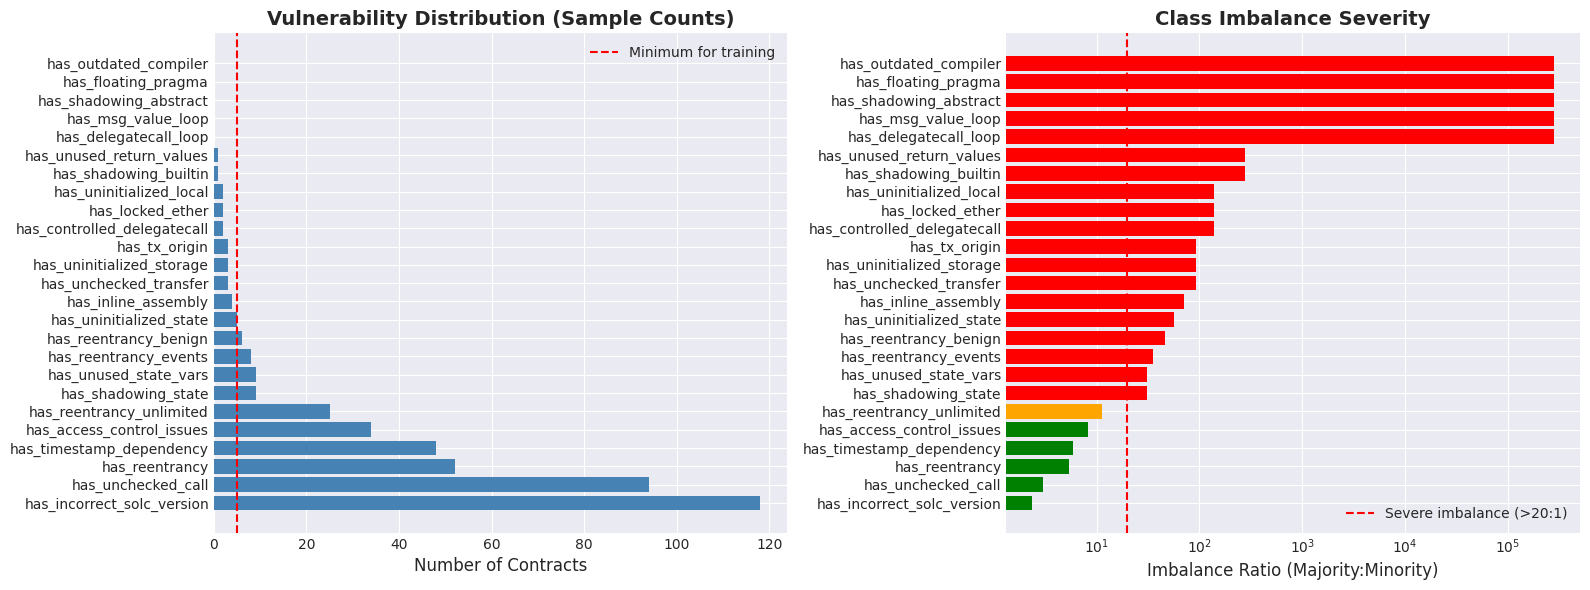


✅ Saved: notebooks/01_vulnerability_distribution.png


In [4]:
# ═══════════════════════════════════════════════════════════════
# VISUALIZATION 1: Vulnerability Distribution
# ═══════════════════════════════════════════════════════════════

# Create dataframe for plotting
vuln_stats = pd.DataFrame({
    'vulnerability': vuln_counts.index,
    'count': vuln_counts.values,
    'percentage': (vuln_counts.values / len(df_clean)) * 100
})

# Calculate imbalance ratio
vuln_stats['ratio'] = len(df_clean) / (vuln_stats['count'] + 0.001)

# Sort by count
vuln_stats = vuln_stats.sort_values('count', ascending=False)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Sample counts
ax1.barh(vuln_stats['vulnerability'], vuln_stats['count'], color='steelblue')
ax1.set_xlabel('Number of Contracts', fontsize=12)
ax1.set_title('Vulnerability Distribution (Sample Counts)', fontsize=14, fontweight='bold')
ax1.axvline(x=5, color='red', linestyle='--', label='Minimum for training')
ax1.legend()

# Bar chart: Imbalance ratios (log scale)
colors = ['green' if r < 10 else 'orange' if r < 20 else 'red' 
          for r in vuln_stats['ratio']]
ax2.barh(vuln_stats['vulnerability'], vuln_stats['ratio'], color=colors)
ax2.set_xlabel('Imbalance Ratio (Majority:Minority)', fontsize=12)
ax2.set_title('Class Imbalance Severity', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.axvline(x=20, color='red', linestyle='--', label='Severe imbalance (>20:1)')
ax2.legend()

plt.tight_layout()
plt.savefig('/home/motafeq/projects/chainguardian-ai/notebooks/01_vulnerability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: notebooks/01_vulnerability_distribution.png")

In [5]:
# ═══════════════════════════════════════════════════════════════
# KEY FINDINGS - SESSION 1A
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("SESSION 1A - KEY FINDINGS")
print("="*70)

print(f"\n1. DATASET SIZE:")
print(f"   • Original: 312 contracts")
print(f"   • After deduplication: {len(df_clean)} contracts")
print(f"   • Features: {len(feature_cols)}")

print(f"\n2. VULNERABILITY LANDSCAPE:")
print(f"   • Total vulnerability types: {len(vuln_cols)}")
print(f"   • Trainable (5+ samples): {len(priority_vulns)}")
print(f"   • Very rare (1-4 samples): {len(rare_vulns)}")
print(f"   • No samples (skip): {len(zero_sample_vulns)}")

print(f"\n3. CLASS IMBALANCE SEVERITY:")
most_balanced = vuln_stats.nsmallest(3, 'ratio')
most_imbalanced = vuln_stats.nlargest(3, 'ratio')[vuln_stats['count'] > 0]

print(f"   Most balanced:")
for _, row in most_balanced.iterrows():
    print(f"      • {row['vulnerability']}: {row['ratio']:.1f}:1 ratio")

print(f"   Most imbalanced (with samples):")
for _, row in most_imbalanced.iterrows():
    print(f"      • {row['vulnerability']}: {row['ratio']:.1f}:1 ratio")

print(f"\n4. NEXT STEPS:")
print(f"   • Session 1B: Analyze feature distributions")
print(f"   • Session 1C: Feature-vulnerability correlations")
print(f"   • Session 1D: Generate hypotheses for feature engineering")

print("\n" + "="*70)

# Save cleaned dataset for next sessions
df_clean.to_csv('/home/motafeq/projects/chainguardian-ai/data/chainguardian_features_clean_dedup.csv', index=False)
print(f"\n✅ Saved clean dataset: home/motafeq/projects/chainguardian-ai/data/chainguardian_features_clean_dedup.csv")
print(f"✅ Session 1A complete! Take 15-min break, then start Session 1B.")


SESSION 1A - KEY FINDINGS

1. DATASET SIZE:
   • Original: 312 contracts
   • After deduplication: 281 contracts
   • Features: 35

2. VULNERABILITY LANDSCAPE:
   • Total vulnerability types: 25
   • Trainable (5+ samples): 11
   • Very rare (1-4 samples): 9
   • No samples (skip): 5

3. CLASS IMBALANCE SEVERITY:
   Most balanced:
      • has_incorrect_solc_version: 2.4:1 ratio
      • has_unchecked_call: 3.0:1 ratio
      • has_reentrancy: 5.4:1 ratio
   Most imbalanced (with samples):

4. NEXT STEPS:
   • Session 1B: Analyze feature distributions
   • Session 1C: Feature-vulnerability correlations
   • Session 1D: Generate hypotheses for feature engineering


✅ Saved clean dataset: home/motafeq/projects/chainguardian-ai/data/chainguardian_features_clean_dedup.csv
✅ Session 1A complete! Take 15-min break, then start Session 1B.


In [ ]:
# Quick H2O Analysis - Simplified
import h2o
from h2o.automl import H2OAutoML
import pandas as pd

# Initialize H2O
h2o.init(max_mem_size='4G')

# Load data
df = pd.read_csv('/home/motafeq/projects/chainguardian-ai/data/chainguardian_features_clean_dedup.csv')
hf = h2o.H2OFrame(df)

# Identify columns
vuln_cols = [c for c in df.columns if c.startswith('has_')]
feature_cols = [c for c in df.columns if c not in 
                ['contract_id', 'contract_name', 'address', 'file_path', 'compiler_version'] + vuln_cols]

# Pick one vulnerability to test
vuln = 'has_reentrancy'  # Change this to any vulnerability you want to test
if vuln in hf.columns:
    print(f"Training on {vuln}...")
    
    # Split data
    train, test = hf.split_frame(ratios=[0.8], seed=42)
    
    # Run AutoML (quick run)
    aml = H2OAutoML(max_runtime_secs=60, seed=42)
    aml.train(x=feature_cols, y=vuln, training_frame=train)
    
    # View leaderboard
    print("\nLeaderboard:")
    print(aml.leaderboard)
    
    # Test best model
    perf = aml.leader.model_performance(test)
    print(f"\nTest AUC: {perf.auc():.4f}")
    
    # Make predictions
    preds = aml.leader.predict(test)
    print("\nSample predictions:")
    print(preds.head())

# Shutdown
h2o.shutdown()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-124.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-124.04, mixed mode, sharing)
  Starting server from /home/motafeq/projects/chainguardian-ai/.venv/lib/python3.12/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp02zyxwrm
  JVM stdout: /tmp/tmp02zyxwrm/h2o_motafeq_started_from_python.out
  JVM stderr: /tmp/tmp02zyxwrm/h2o_motafeq_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
